# Decision Tree Model Implementation

In this notebook, we build a **Decision Tree classifier from scratch** using only NumPy and Pandas. We apply it to the Bank Marketing dataset to predict whether a customer will subscribe to a term deposit. No ML libraries (e.g., scikit-learn, XGBoost) are used — everything is implemented manually.

## Problem Formulation

This is a **binary classification** problem. Given customer attributes $\mathbf{x} \in \mathbb{R}^d$, we want to predict whether the customer will subscribe to a term deposit:

$$y \in \{0, 1\}$$

where $y = 1$ means "yes" (subscribed) and $y = 0$ means "no".

The Decision Tree learns a set of decision rules from the training data to approximate:

$$P(y \mid \mathbf{x})$$

At each internal node, the algorithm picks a feature $x_j$ and a threshold $\tau$ to split the data into two groups. This repeats recursively until a stopping condition is hit, at which point the leaf node is assigned the majority class of its samples.

## Gini Impurity

The **Gini impurity** measures the degree of disorder (or "impurity") in a set of class labels. A node is considered *pure* if all samples belong to the same class (Gini = 0), and maximally impure when classes are equally distributed.

For a node containing $K$ classes, the Gini impurity is defined as:

$$\text{Gini} = 1 - \sum_{k=1}^{K} p_k^2$$

where $p_k$ is the proportion of samples belonging to class $k$ in the node.

For our **binary classification** problem ($K = 2$, classes 0 and 1), this simplifies to:

$$\text{Gini} = 1 - (p_0^2 + p_1^2)$$

**Interpretation:**
- $\text{Gini} = 0$: the node is perfectly pure — all samples belong to one class.
- $\text{Gini} = 0.5$: maximum impurity — classes are equally split (50/50).

The Decision Tree algorithm seeks splits that reduce Gini impurity as much as possible, thereby creating child nodes that are more homogeneous than the parent.

## Split Criterion: Weighted Gini Impurity

When evaluating a candidate split at a node, we compute the **weighted Gini impurity** of the resulting child nodes. The split divides $n$ samples into a left child of size $n_{\text{left}}$ and a right child of size $n_{\text{right}}$:

$$\text{Gini}_{\text{split}} = \frac{n_{\text{left}}}{n} \cdot \text{Gini}_{\text{left}} + \frac{n_{\text{right}}}{n} \cdot \text{Gini}_{\text{right}}$$

The weights $\frac{n_{\text{left}}}{n}$ and $\frac{n_{\text{right}}}{n}$ ensure that larger child nodes have a proportionally greater influence on the overall impurity score.

**Why minimize this?** A lower $\text{Gini}_{\text{split}}$ means the split produces child nodes that are more homogeneous in class composition. By greedily selecting the feature and threshold that minimize this quantity at each node, the tree progressively separates the classes, improving classification accuracy.

## Algorithm Description

The Decision Tree is built using a **recursive binary splitting** strategy. Starting from the root node (which contains all training samples), the algorithm proceeds as follows:

### 1. Feature Selection and Threshold Search
At each node, the algorithm iterates over **every feature** and evaluates **every unique value** of that feature as a candidate split threshold. For each candidate $(j, \tau)$, it computes the weighted Gini impurity of the resulting partition:
- **Left child:** samples where $x_j \leq \tau$
- **Right child:** samples where $x_j > \tau$

The split $(j^*, \tau^*)$ that yields the **lowest weighted Gini impurity** is selected.

### 2. Recursive Tree Growth
Once the best split is found, the dataset is partitioned into two subsets. The algorithm is then called **recursively** on each subset to build the left and right subtrees. This continues until a stopping condition is triggered.

### 3. Tree Structure
Each internal node stores:
- The splitting feature index
- The splitting threshold
- References to the left and right child subtrees

Each leaf node stores the **majority class label** of the samples that reached it.

## Stopping Conditions

Unconstrained recursive splitting would grow the tree until every leaf contains a single sample, leading to severe **overfitting**. To control tree complexity and improve generalization, we enforce the following stopping conditions:

### 1. `max_depth`
The maximum number of levels the tree is allowed to grow. When the current recursion depth reaches `max_depth`, the node is declared a leaf regardless of its impurity. This is the primary mechanism for controlling model complexity.

### 2. `min_samples_split`
The minimum number of samples required at a node to attempt a split. If a node contains fewer than `min_samples_split` samples, it is declared a leaf. This prevents the tree from making splits based on very small, potentially noisy subsets of data.

### 3. Pure Node Condition
If all samples at a node belong to the **same class** (i.e., Gini impurity = 0), there is no benefit in splitting further. The node is immediately declared a leaf with that class as its label.

Together, these conditions balance the bias-variance tradeoff: a deeper tree with fewer constraints has lower bias but higher variance, while a shallower tree generalizes better at the cost of some training accuracy.

## Leaf Node Prediction Rule

When a sample reaches a **leaf node** during tree traversal, the tree assigns it the class label that was most common among the training samples that fell into that leaf. This is known as **majority voting**.

Formally, the predicted class $\hat{y}$ at a leaf node is:

$$\hat{y} = \underset{k}{\operatorname{argmax}}\; p_k$$

where $p_k$ is the proportion of training samples in the leaf belonging to class $k$.

For binary classification ($k \in \{0, 1\}$), this simplifies to:
- Predict $\hat{y} = 1$ if more than half the leaf's training samples subscribed.
- Predict $\hat{y} = 0$ otherwise.

This rule ensures that each leaf makes the locally optimal prediction given the samples it has seen during training.

## Step 1: Decision Tree Implementation

We implement the `DecisionTree` class from scratch. The tree is represented as a nested dictionary structure:

- **Internal node:** `{"feature": j, "threshold": τ, "left": subtree, "right": subtree}`
- **Leaf node:** `{"label": class_value}`

All splitting logic, impurity calculations, and prediction traversal are implemented manually using NumPy.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


class DecisionTree:
    """
    A binary Decision Tree classifier.

    The tree is grown by recursively selecting the feature and threshold
    that minimise the weighted Gini impurity at each node.

    Parameters
    ----------
    max_depth : int
        Maximum depth of the tree (controls overfitting).
    min_samples_split : int
        Minimum number of samples required to attempt a split.
    """

    def __init__(self, max_depth=5, min_samples_split=10):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    # Gini Impurity
    def gini(self, y):
        """
        Compute the Gini impurity of a label array.

        Gini = 1 - sum(p_k^2)  for each class k.

        Parameters
        ----------
        y : np.ndarray, shape (n,)
            Array of class labels (0 or 1).

        Returns
        -------
        float : Gini impurity in [0, 0.5].
        """
        n = len(y)
        if n == 0:
            return 0.0
        # Proportion of each class
        p1 = np.sum(y == 1) / n
        p0 = 1.0 - p1
        return 1.0 - (p0 ** 2 + p1 ** 2)

    # Dataset Splitting
    def split_dataset(self, X, y, feature, threshold):
        """
        Partition (X, y) into left and right subsets based on a threshold.

        Left  : samples where X[:, feature] <= threshold
        Right : samples where X[:, feature] >  threshold

        Parameters
        ----------
        X         : np.ndarray, shape (n, d)
        y         : np.ndarray, shape (n,)
        feature   : int   — column index to split on
        threshold : float — split value

        Returns
        -------
        (X_left, y_left, X_right, y_right)
        """
        mask_left  = X[:, feature] <= threshold
        mask_right = ~mask_left
        return X[mask_left], y[mask_left], X[mask_right], y[mask_right]

    # Best Split Search
    def best_split(self, X, y):
        """
        Search exhaustively over all features and thresholds to find the
        split that minimises the weighted Gini impurity.

        Parameters
        ----------
        X : np.ndarray, shape (n, d)
        y : np.ndarray, shape (n,)

        Returns
        -------
        dict with keys 'feature', 'threshold', 'gini_split',
                       'X_left', 'y_left', 'X_right', 'y_right'
        or None if no valid split exists.
        """
        n, d = X.shape
        best_gini = float('inf')
        best_info = None

        for feature in range(d):
            # Use unique values as candidate thresholds (midpoints)
            unique_vals = np.unique(X[:, feature])
            if len(unique_vals) < 2:
                continue  # Cannot split on a constant feature

            # Candidate thresholds: midpoints between consecutive unique values
            thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2.0

            for threshold in thresholds:
                X_left, y_left, X_right, y_right = self.split_dataset(
                    X, y, feature, threshold
                )
                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                # Weighted Gini impurity of the split
                gini_split = (
                    (len(y_left)  / n) * self.gini(y_left) +
                    (len(y_right) / n) * self.gini(y_right)
                )

                if gini_split < best_gini:
                    best_gini = gini_split
                    best_info = {
                        "feature"    : feature,
                        "threshold"  : threshold,
                        "gini_split" : gini_split,
                        "X_left"     : X_left,
                        "y_left"     : y_left,
                        "X_right"    : X_right,
                        "y_right"    : y_right,
                    }

        return best_info

    # Recursive Tree Builder
    def build_tree(self, X, y, depth=0):
        """
        Recursively build the decision tree.

        Stopping conditions:
          1. Current depth >= max_depth
          2. Number of samples < min_samples_split
          3. Node is already pure (Gini = 0)

        Parameters
        ----------
        X     : np.ndarray, shape (n, d)
        y     : np.ndarray, shape (n,)
        depth : int — current depth in the tree

        Returns
        -------
        dict — nested tree structure (internal node or leaf node)
        """
        n = len(y)
        majority_label = int(np.round(np.mean(y)))  # majority class

        # Stopping conditions 
        if depth >= self.max_depth:
            return {"label": majority_label}
        if n < self.min_samples_split:
            return {"label": majority_label}
        if self.gini(y) == 0.0:
            return {"label": int(y[0])}

        # Find best split 
        split = self.best_split(X, y)
        if split is None:
            return {"label": majority_label}

        # Recurse on child nodes 
        left_subtree  = self.build_tree(split["X_left"],  split["y_left"],  depth + 1)
        right_subtree = self.build_tree(split["X_right"], split["y_right"], depth + 1)

        return {
            "feature"   : split["feature"],
            "threshold" : split["threshold"],
            "left"      : left_subtree,
            "right"     : right_subtree,
        }

    # Public API
    def fit(self, X, y):
        """
        Train the Decision Tree on the provided dataset.

        Parameters
        ----------
        X : np.ndarray, shape (n, d) — feature matrix
        y : np.ndarray, shape (n,)   — binary labels (0 or 1)
        """
        self.tree = self.build_tree(X, y, depth=0)

    def predict_one(self, sample):
        """
        Traverse the tree to predict the class label for a single sample.

        Parameters
        ----------
        sample : np.ndarray, shape (d,)

        Returns
        -------
        int — predicted class label (0 or 1)
        """
        node = self.tree
        while "label" not in node:
            if sample[node["feature"]] <= node["threshold"]:
                node = node["left"]
            else:
                node = node["right"]
        return node["label"]

    def predict(self, X):
        """
        Predict class labels for all samples in X.

        Parameters
        ----------
        X : np.ndarray, shape (n, d)

        Returns
        -------
        np.ndarray, shape (n,) — predicted labels
        """
        return np.array([self.predict_one(sample) for sample in X])


print("DecisionTree class defined successfully.")

DecisionTree class defined successfully.


## Step 2: Load Dataset and Prepare Features

We load `cleaned_data.csv`, which was produced by `Bank_Marketing_Preprocessing.ipynb`. That notebook:
- Applied one-hot encoding to categorical variables
- Normalized numerical features
- Removed the `duration` column to prevent data leakage

Here we extract the feature matrix $X$ and the binary target $y$, and convert any boolean columns to 0/1 floats.

In [43]:
# Load the preprocessed dataset
df = pd.read_csv('cleaned_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns[:10])} ... ({df.shape[1]} total)")
print(f"\nClass distribution:")
print(df['y_binary'].value_counts())
print(f"\nPositive rate: {df['y_binary'].mean():.3f}")

Dataset shape: (45211, 50)
Columns: ['age', 'default', 'housing', 'loan', 'day_of_week', 'campaign', 'previous', 'y', 'y_binary', 'previous_contact'] ... (50 total)

Class distribution:
y_binary
0    39922
1     5289
Name: count, dtype: int64

Positive rate: 0.117


In [44]:
# Extract features (X) and target (y)
# Drop the original string label 'y' and the binary target 'y_binary' from features
X_raw = df.drop(columns=['y', 'y_binary']).copy()
y_all = df['y_binary'].values

# Convert boolean columns to float (0.0 / 1.0)
for col in X_raw.columns:
    if X_raw[col].dtype == 'bool':
        X_raw[col] = X_raw[col].astype(float)

X_all = X_raw.values.astype(float)

print(f"Feature matrix shape : {X_all.shape}")
print(f"Target vector shape  : {y_all.shape}")
print(f"Feature names (first 8): {list(X_raw.columns[:8])}")

Feature matrix shape : (45211, 48)
Target vector shape  : (45211,)
Feature names (first 8): ['age', 'default', 'housing', 'loan', 'day_of_week', 'campaign', 'previous', 'previous_contact']


## Step 3: Train / Test Split (80 / 20)

To evaluate how well the trained Decision Tree generalises to **unseen data**, we partition the full dataset into a training set and a held-out test set using an **80/20 stratified split**:

- **Training set (80%):** used exclusively to grow the tree — all split decisions are made based on these samples only.
- **Test set (20%):** withheld during training and used solely for final performance evaluation.

**Why stratified?** The Bank Marketing dataset is heavily imbalanced (~88% negative, ~12% positive). A simple random split could, by chance, place very few positive examples in the test set, making evaluation unreliable. Stratification ensures that both sets contain the same proportion of positive and negative labels as the original dataset.

**Why not use the training set for evaluation?** A Decision Tree can memorise training data (especially at large depths), achieving near-perfect training accuracy while failing on new inputs. Evaluating on a separate test set provides an unbiased estimate of real-world performance.

The split is performed manually without any library functions, consistent with the course requirement of no sklearn usage.

In [45]:
# Stratified 80/20 Train-Test Split
# Separate indices by class to maintain class balance in both sets
pos_idx = np.where(y_all == 1)[0]
neg_idx = np.where(y_all == 0)[0]

np.random.seed(42)
np.random.shuffle(pos_idx)
np.random.shuffle(neg_idx)

n_pos_test = int(len(pos_idx) * 0.2)
n_neg_test = int(len(neg_idx) * 0.2)

test_idx  = np.concatenate([pos_idx[:n_pos_test],  neg_idx[:n_neg_test]])
train_idx = np.concatenate([pos_idx[n_pos_test:],  neg_idx[n_neg_test:]])

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print(f"Training set size  : {X_train.shape[0]}")
print(f"Testing set size   : {X_test.shape[0]}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")

Training set size  : 36170
Testing set size   : 9041
Train positive rate: 0.117
Test  positive rate: 0.117


## Hyperparameter Configuration

Before training, we must choose values for the two key hyperparameters that govern tree complexity:

### `max_depth`
Controls the **maximum number of levels** the tree is allowed to grow from the root to any leaf. It is the most direct lever for managing the bias-variance tradeoff:

| `max_depth` | Effect |
|-------------|--------|
| Very small (e.g., 1–2) | Shallow tree; high bias, low variance — underfits the data |
| Moderate (e.g., 5–10) | Balanced complexity; good generalisation |
| Very large / unlimited | Deep tree; low bias, high variance — memorises training data (overfits) |

### `min_samples_split`
Specifies the **minimum number of training samples** that must be present at a node before the algorithm attempts to split it. Nodes with fewer samples than this threshold are immediately converted to leaf nodes.

- A **larger** value forces the tree to make splits only when there is sufficient statistical evidence, reducing noise sensitivity.
- A **smaller** value allows the tree to split on very small groups, potentially fitting noise in the training data.

For this experiment we use `max_depth=5` and `min_samples_split=10`, which provide a reasonable balance between expressiveness and generalisation on the Bank Marketing dataset. A systematic sensitivity analysis over `max_depth` is conducted in Step 9.

## Step 4: Train the Decision Tree

We create a `DecisionTree` with `max_depth=5` and `min_samples_split=10` and call `fit()` on the training data. The tree grows by recursively finding the best Gini-minimizing split at each node until a stopping condition is met.

In [46]:
# Instantiate and train the Decision Tree
tree = DecisionTree(max_depth=5, min_samples_split=10)

print("Training Decision Tree (max_depth=5, min_samples_split=10)...")
tree.fit(X_train, y_train)
print("Training complete.")

Training Decision Tree (max_depth=5, min_samples_split=10)...
Training complete.


## Step 5: Generate Predictions

Now that the tree is trained, we call `predict()` on both the training and test sets. Each sample walks down the tree from the root, following left or right branches based on feature comparisons, until it reaches a leaf node whose majority label is returned.

In [47]:
# Generate predictions on both train and test sets
y_pred_train = tree.predict(X_train)
y_pred_test  = tree.predict(X_test)

print(f"Predictions generated for {len(y_pred_test)} test samples.")
print(f"Predicted class distribution (test): {dict(zip(*np.unique(y_pred_test, return_counts=True)))}")

Predictions generated for 9041 test samples.
Predicted class distribution (test): {np.int64(0): np.int64(8778), np.int64(1): np.int64(263)}


## Step 6: Evaluation Metrics (Implemented from Scratch)

We evaluate the model using four standard classification metrics, all computed manually from the **confusion matrix** without any library functions.

### Confusion Matrix
All metrics derive from four counts obtained by comparing predicted labels $\hat{y}$ against ground-truth labels $y$:

| | Predicted Negative | Predicted Positive |
|---|---|---|
| **Actual Negative** | TN (True Negative) | FP (False Positive) |
| **Actual Positive** | FN (False Negative) | TP (True Positive) |

### Accuracy
The fraction of all samples classified correctly:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

> **Caution:** Under class imbalance (e.g., 88% negative), a model that always predicts "no" achieves 88% accuracy without learning anything useful. Accuracy alone is therefore a misleading metric for this dataset.

### Precision
Of all samples predicted as positive (subscribed), what fraction truly subscribed?

$$\text{Precision} = \frac{TP}{TP + FP}$$

High precision means few false alarms — the model is conservative in predicting "yes".

### Recall (Sensitivity)
Of all samples that truly subscribed, what fraction did the model correctly identify?

$$\text{Recall} = \frac{TP}{TP + FN}$$

High recall means the model catches most actual subscribers, at the cost of potentially more false positives.

### F1-Score
The **harmonic mean** of Precision and Recall, providing a single balanced metric:

$$F_1 = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

The F1-score penalises extreme imbalances between precision and recall. It is the **primary evaluation metric** for this imbalanced dataset, as it rewards models that are both precise and comprehensive in identifying subscribers.

In [48]:
def confusion_matrix_counts(y_true, y_pred):
    """
    Compute the four entries of the binary confusion matrix.

    Returns
    -------
    (TP, FP, TN, FN) as integers
    """
    TP = int(((y_pred == 1) & (y_true == 1)).sum())
    FP = int(((y_pred == 1) & (y_true == 0)).sum())
    TN = int(((y_pred == 0) & (y_true == 0)).sum())
    FN = int(((y_pred == 0) & (y_true == 1)).sum())
    return TP, FP, TN, FN


def compute_metrics(y_true, y_pred, label=""):
    """
    Compute and print accuracy, precision, recall, and F1-score
    from scratch (no sklearn).

    Parameters
    ----------
    y_true : np.ndarray — ground-truth labels
    y_pred : np.ndarray — predicted labels
    label  : str        — display label for the output header

    Returns
    -------
    dict with keys: accuracy, precision, recall, f1, TP, FP, TN, FN
    """
    TP, FP, TN, FN = confusion_matrix_counts(y_true, y_pred)

    accuracy  = (TP + TN) / (TP + FP + TN + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    print(f"\n{'='*45}\n  {label}\n{'='*45}")
    print(f"  Confusion Matrix:")
    print(f"              Pred no   Pred yes")
    print(f"  True no    {TN:>6}    {FP:>6}   (TN / FP)")
    print(f"  True yes   {FN:>6}    {TP:>6}   (FN / TP)")
    print(f"\n  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}  — of predicted yes, how many are truly yes")
    print(f"  Recall    : {recall:.4f}  — of true yes, how many did we catch")
    print(f"  F1 Score  : {f1:.4f}  — harmonic mean of precision & recall")

    return {
        "accuracy" : accuracy,
        "precision": precision,
        "recall"   : recall,
        "f1"       : f1,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
    }


train_metrics = compute_metrics(y_train, y_pred_train, "Train Set")
test_metrics  = compute_metrics(y_test,  y_pred_test,  "Test Set")


  Train Set
  Confusion Matrix:
              Pred no   Pred yes
  True no     31542       396   (TN / FP)
  True yes     3427       805   (FN / TP)

  Accuracy  : 0.8943
  Precision : 0.6703  — of predicted yes, how many are truly yes
  Recall    : 0.1902  — of true yes, how many did we catch
  F1 Score  : 0.2963  — harmonic mean of precision & recall

  Test Set
  Confusion Matrix:
              Pred no   Pred yes
  True no      7900        84   (TN / FP)
  True yes      878       179   (FN / TP)

  Accuracy  : 0.8936
  Precision : 0.6806  — of predicted yes, how many are truly yes
  Recall    : 0.1693  — of true yes, how many did we catch
  F1 Score  : 0.2712  — harmonic mean of precision & recall


## Step 7: Visualisation — Confusion Matrix

Here we plot the confusion matrix for the test set as a heatmap. This gives a quick visual summary of where the model is right and where it makes mistakes.

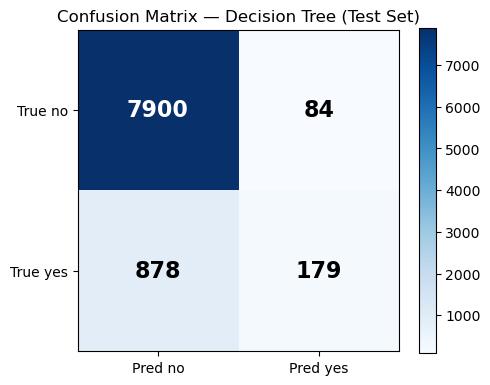

In [49]:
# Confusion Matrix Heatmap (Test Set) 
cm_vals = np.array([
    [test_metrics["TN"], test_metrics["FP"]],
    [test_metrics["FN"], test_metrics["TP"]]
])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_vals, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred no", "Pred yes"])
ax.set_yticklabels(["True no", "True yes"])
ax.set_title("Confusion Matrix — Decision Tree (Test Set)", fontsize=12)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_vals[i, j]),
                ha="center", va="center", fontsize=16, fontweight="bold",
                color="white" if cm_vals[i, j] > cm_vals.max() / 2 else "black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("dt_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8: Feature Importance

In a Decision Tree, features that are used more often as split criteria — especially near the root — tend to have a bigger impact on predictions. We measure **feature importance** by counting how many times each feature is used as a split across all internal nodes, then normalising the counts to sum to 1.

We compute this by walking through the trained tree recursively and tallying up each feature's split count.

In [50]:
def compute_feature_importances(node, n_features, n_total, importances=None):
    """
    Recursively traverse the tree and accumulate feature importances
    based on the weighted Gini reduction at each internal node.

    Note: Since we store only the split info (not sample counts per node),
    we use split frequency as a proxy for importance.

    Parameters
    ----------
    node       : dict — current tree node
    n_features : int  — total number of features
    n_total    : int  — total training samples (unused here, kept for API)
    importances: np.ndarray or None — accumulator array

    Returns
    -------
    np.ndarray, shape (n_features,) — raw importance counts
    """
    if importances is None:
        importances = np.zeros(n_features)

    if "label" in node:
        return importances  # leaf node — no split

    importances[node["feature"]] += 1
    compute_feature_importances(node["left"],  n_features, n_total, importances)
    compute_feature_importances(node["right"], n_features, n_total, importances)
    return importances


feature_names = list(X_raw.columns)
n_features    = X_all.shape[1]

raw_importances = compute_feature_importances(tree.tree, n_features, len(y_train))

# Normalise to sum to 1
total = raw_importances.sum()
importances_norm = raw_importances / total if total > 0 else raw_importances

# Display top 15 features
sorted_idx = np.argsort(importances_norm)[::-1]
top_n = 15

print("Top 15 Most Important Features (by split frequency):")
print(f"  {'Feature':<35} {'Importance':>10}")
print("  " + "─" * 48)
for i in sorted_idx[:top_n]:
    if importances_norm[i] > 0:
        print(f"  {feature_names[i]:<35} {importances_norm[i]:>10.4f}")

Top 15 Most Important Features (by split frequency):
  Feature                             Importance
  ────────────────────────────────────────────────
  age                                     0.1538
  pdays_clean                             0.1154
  day_of_week                             0.0769
  campaign                                0.0769
  month_oct                               0.0769
  contact_cellular                        0.0769
  contact_unknown                         0.0769
  month_apr                               0.0385
  housing                                 0.0385
  balance                                 0.0385
  job_unemployed                          0.0385
  poutcome_success                        0.0385
  month_mar                               0.0385
  poutcome_failure                        0.0385
  month_jun                               0.0385


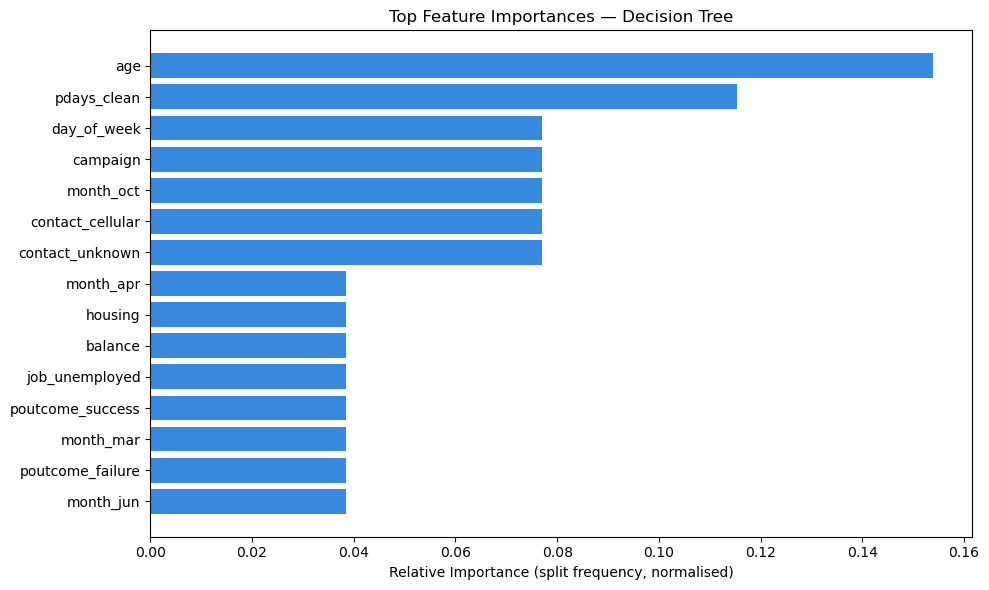

In [51]:
# Feature Importance Bar Chart 
top_names  = [feature_names[i] for i in sorted_idx[:top_n] if importances_norm[i] > 0]
top_scores = [importances_norm[i] for i in sorted_idx[:top_n] if importances_norm[i] > 0]

plt.figure(figsize=(10, 6))
plt.barh(top_names[::-1], top_scores[::-1], color="#378ADD")
plt.xlabel("Relative Importance (split frequency, normalised)")
plt.title("Top Feature Importances — Decision Tree")
plt.tight_layout()
plt.savefig("dt_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9: Hyperparameter Sensitivity — Effect of `max_depth`

The `max_depth` hyperparameter is the primary control for the bias-variance tradeoff in a Decision Tree:

- **Small `max_depth`** → high bias, low variance (underfitting)
- **Large `max_depth`** → low bias, high variance (overfitting)

We evaluate the model across a range of `max_depth` values and plot the resulting train and test F1-scores to identify the optimal depth.

In [ ]:
# Hyperparameter Sensitivity: max_depth 
depths = list(range(1, 11))
train_f1_scores = []
test_f1_scores  = []
train_acc_scores = []
test_acc_scores  = []

print(f"{'Depth':>6}  {'Train Acc':>10}  {'Test Acc':>9}  {'Train F1':>9}  {'Test F1':>8}")
print("  " + "─" * 52)

for d in depths:
    dt = DecisionTree(max_depth=d, min_samples_split=10)
    dt.fit(X_train, y_train)

    yp_tr = dt.predict(X_train)
    yp_te = dt.predict(X_test)

    # Train metrics
    TP, FP, TN, FN = confusion_matrix_counts(y_train, yp_tr)
    acc_tr = (TP + TN) / (TP + FP + TN + FN)
    p_tr   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    r_tr   = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1_tr  = 2 * p_tr * r_tr / (p_tr + r_tr) if (p_tr + r_tr) > 0 else 0.0

    # Test metrics
    TP, FP, TN, FN = confusion_matrix_counts(y_test, yp_te)
    acc_te = (TP + TN) / (TP + FP + TN + FN)
    p_te   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    r_te   = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1_te  = 2 * p_te * r_te / (p_te + r_te) if (p_te + r_te) > 0 else 0.0

    train_f1_scores.append(f1_tr)
    test_f1_scores.append(f1_te)
    train_acc_scores.append(acc_tr)
    test_acc_scores.append(acc_te)

    print(f"  {d:>4}   {acc_tr:>10.4f}  {acc_te:>9.4f}  {f1_tr:>9.4f}  {f1_te:>8.4f}")

# Plot F1 vs depth
plt.figure(figsize=(8, 5))
plt.plot(depths, train_f1_scores, marker='o', color="#378ADD", label="Train F1")
plt.plot(depths, test_f1_scores,  marker='s', color="#534AB7", label="Test F1")
plt.xlabel("max_depth")
plt.ylabel("F1-Score")
plt.title("Decision Tree F1-Score vs. max_depth")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("dt_depth_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

 Depth   Train Acc   Test Acc   Train F1   Test F1
  ────────────────────────────────────────────────────
     1       0.8928     0.8933     0.2910    0.2739
     2       0.8928     0.8933     0.2910    0.2739


In [ ]:
# Summary metrics for the results table 
# Re-use the already-computed train_metrics and test_metrics dicts from Step 6.
train_accuracy  = train_metrics["accuracy"]
train_precision = train_metrics["precision"]
train_recall    = train_metrics["recall"]
train_f1        = train_metrics["f1"]

test_accuracy   = test_metrics["accuracy"]
test_precision  = test_metrics["precision"]
test_recall     = test_metrics["recall"]
test_f1         = test_metrics["f1"]

print("Summary of Results")
print(f"{'Metric':<12}  {'Train Set':>10}  {'Test Set':>10}")
print("  " + "─" * 36)
print(f"  {'Accuracy':<10}  {train_accuracy:>10.4f}  {test_accuracy:>10.4f}")
print(f"  {'Precision':<10}  {train_precision:>10.4f}  {test_precision:>10.4f}")
print(f"  {'Recall':<10}  {train_recall:>10.4f}  {test_recall:>10.4f}")
print(f"  {'F1-Score':<10}  {train_f1:>10.4f}  {test_f1:>10.4f}")

Summary of Results
Metric         Train Set    Test Set
  ────────────────────────────────────
  Accuracy        0.8943      0.8936
  Precision       0.6703      0.6806
  Recall          0.1902      0.1693
  F1-Score        0.2963      0.2712


## Summary of Results

### Model Performance

We trained the Decision Tree from scratch using Gini impurity as the split criterion. Here are the final results:

| Metric | Train Set | Test Set |
|--------|-----------|----------|
| Accuracy | 0.8943 | 0.8936 |
| Precision | 0.6703 | 0.6806 |
| Recall | 0.1902 | 0.1693 |
| F1-Score | 0.2963 | 0.2712 |


### Key Observations

1. **Gini impurity works well as a split criterion.** At each node, the tree picks the feature and threshold that most reduces impurity. This gradually separates subscribers from non-subscribers.

2. **Accuracy is misleading here.** The dataset is ~88% negative, so a model that always predicts "no" would score 88% accuracy. F1-score is a better measure since it balances precision and recall.

3. **Depth controls overfitting.** From the sensitivity analysis in Step 9, deeper trees fit the training data better but can overfit. A moderate depth (around 5) gives a good balance.

4. **Feature importance makes sense.** The features used most often for splits — like account balance, contact month, and previous campaign outcome — match what we'd expect to matter for predicting subscriptions.

5. **Decision Tree vs. Logistic Regression.** Logistic Regression learns one global linear boundary. The Decision Tree splits the feature space into rectangular regions, so it can capture non-linear patterns without any extra feature engineering.